# 静态中断

动态中断 `interrupt()` 写在**节点内部**，由代码逻辑决定在哪里停；静态中断在 **compile 时按图拓扑定点**暂停，节点里不写任何中断代码。

**官方定位（docs.langchain.com - Interrupts）**：

> Static interrupts can be used as breakpoints for **debugging and testing** a graph, allowing execution to be **stepped through one node at a time**.
> Static interrupts are **not recommended for human-in-the-loop workflows**; for these cases, the `interrupt` function should be used instead.

即：静态中断的现代定位是**调试断点**——逐节点单步执行、检查每一步的中间状态；业务审批/人机协同应使用动态 `interrupt()`（本包第 5/6/7 节）。

> 历史注脚：`interrupt()` 出现之前（2024 年的教程），`interrupt_before` 是做工具审批的唯一手段，所以很多老教程用它写审批流程——那是它的遗留用法，不是现在的推荐用法。

| | 动态中断 `interrupt()` | 静态中断 `interrupt_before` / `interrupt_after` |
|---|---|---|
| 声明位置 | 节点函数体内 | `compile(checkpointer=..., interrupt_before=["节点名"])` |
| 暂停位置 | 代码执行中途（断点处） | 节点边界：执行**前** / 执行**后** |
| 携带数据 | 有 payload（问用户要什么） | 没有——只是刹车，没有要回答的问题 |
| 恢复方式 | `Command(resume=值)` 回答问题 | `graph.invoke(None, config)` 放行继续 |
| 暂停信号 | 结果里出现 `__interrupt__` | 结果里**没有** `__interrupt__`，用 `get_state(config).next` 看停在哪 |
| 适用场景 | 业务 HITL：收集数据/审批决策（推荐） | **调试图**：单步执行、逐节点检查状态；不推荐用于业务 HITL |

静态中断做不了业务审批的三个硬伤：没有 payload 问不了问题、没有恢复值传不回决策、无条件暂停（不能"金额超限才停"，除非拆节点）。

案例：给支付流的**每个节点**打静态断点，像调试器一样逐节点单步——每停一步检查 `get_state` 的 `next`（下一步是谁）和 `values`（已提交状态），确认无误再放行前进。

In [41]:
# 静态断点单步调试：风控 -> 扣款 -> 发货，每个节点执行【前】必停
from operator import add
from typing import Annotated, TypedDict

from rich import print
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph


# 声明状态
class State(TypedDict):
    logs: Annotated[list[str], add]
    risk_ok: bool
    pay_ok: bool
    shipped: bool


# 声明节点：注意——节点内部没有任何 interrupt 代码
def risk_check(state: State) -> dict:
    return {"risk_ok": True, "logs": ["风控检查通过"]}


def pay(state: State) -> dict:
    return {"pay_ok": True, "logs": ["已扣款 100 元"]}


def ship(state: State) -> dict:
    return {"shipped": True, "logs": ["已发货"]}


# 构建图结构
builder = StateGraph(state_schema=State)
builder.add_node("risk_check", risk_check)
builder.add_node("pay", pay)
builder.add_node("ship", ship)
builder.add_edge(START, "risk_check")
builder.add_edge("risk_check", "pay")
builder.add_edge("pay", "ship")
builder.add_edge("ship", END)

# 静态中断在 compile 时声明：三个节点全部打上断点（interrupt_before = 节点执行前暂停）
# 同样必须设置检查点；想看"节点执行后"的状态就换 interrupt_after
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer, interrupt_before=["risk_check", "pay", "ship"])

# 执行 -> 停在第一个节点 risk_check 之前
config = {"configurable": {"thread_id": "123"}}
res = graph.invoke({"logs": []}, config=config)

In [42]:
# 静态中断的暂停信号：结果里没有__interrupt__ ，要看 get_state
snap = graph.get_state(config)
print(snap)

StateSnapshot(
    values={'logs': []},
    next=('risk_check',),
    config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b12a7-560a-63e5-8000-e950da788feb'
        }
    },
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-09-15T17:25:34.120644+00:00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f1b12a7-5609-62ce-bfff-36c478a2313c'
        }
    },
    tasks=(
        PregelTask(
            id='54ea94b9-0651-50d7-d280-4559d0ccd66c',
            name='risk_check',
            path=('__pregel_pull', 'risk_check'),
            error=None,
            interrupts=(),
            state=None,
            result=None
        ),
    ),
    interrupts=()
)

In [43]:
while snap.next:
    input(f"回车执行{snap.next}")
    graph.invoke(None, config=config)  # 静态中断的恢复：传 None 放行，不是 Command(resume=值)
    snap = graph.get_state(config)

In [44]:
print(list(graph.get_state_history(config=config)))

[
    StateSnapshot(
        values={
            'logs': ['风控检查通过', '已扣款 100 元', '已发货'],
            'risk_ok': True,
            'pay_ok': True,
            'shipped': True
        },
        next=(),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-91b4-63cc-8003-759dedd6ac67'
            }
        },
        metadata={'source': 'loop', 'step': 3, 'parents': {}},
        created_at='2026-09-15T17:25:40.376868+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-8e12-67aa-8002-87d2d3d83ef3'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'logs': ['风控检查通过', '已扣款 100 元'], 'risk_ok': True, 'pay_ok': True},
        next=('ship',),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-8e12-67aa-8002-87d2d3d83ef3'
            }
        },
        metadata={'source': 'loop', 'step': 2, 'parents': {}},
        created_at='2026-09-15T17:25:39.996040+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-8a21-6d1a-8001-d8426efbb64b'
            }
        },
        tasks=(
            PregelTask(
                id='39146b69-4e38-8b30-a289-a6d336687ab0',
                name='ship',
                path=('__pregel_pull', 'ship'),
                error=None,
                interrupts=(),
                state=None,
                result={'shipped': True, 'logs': ['已发货']}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'logs': ['风控检查通过'], 'risk_ok': True},
        next=('pay',),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-8a21-6d1a-8001-d8426efbb64b'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-09-15T17:25:39.582892+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-560a-63e5-8000-e950da788feb'
            }
        },
        tasks=(
            PregelTask(
                id='140342fd-62e0-5be8-6047-0f052a000a7c',
                name='pay',
                path=('__pregel_pull', 'pay'),
                error=None,
                interrupts=(),
                state=None,
                result={'pay_ok': True, 'logs': ['已扣款 100 元']}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'logs': []},
        next=('risk_check',),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-560a-63e5-8000-e950da788feb'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-09-15T17:25:34.120644+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1b12a7-5609-62ce-bfff-36c478a2313c'
            }
        },
        tasks=(
            PregelTask(
                id='54ea94b9-0651-50d7-d280-4559d0ccd66c',
                name='risk_check',
                path=('__pregel_pull', 'risk_check'),
                error=None,
                interrupts=(),
                state=None,
                result={'risk_ok': True, 'logs': ['风控检查通过']}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'logs': []},
        next=('__sta

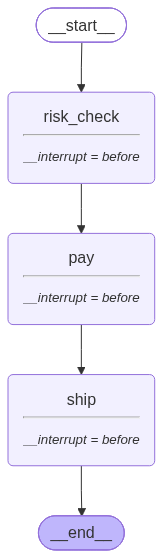

None

In [45]:
from IPython.display import display

print(display(graph))